<center><h1>QBUS2820 Assignment 1 - Predicting Weekly Rent</h1></center>

**Student ID:** SID

1. Setup and data
2. Exploratory data analysis (EDA)
3. Modelling and model selection
4. Final model and predictions

`WeeklyRent_training.csv` and `WeeklyRent_test_noLabel.csv` must be in the same folder as this notebook.

## 1. Setup and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set_context('notebook')
sns.set_style('ticks')

### Data

Load the training data (with `WeeklyRent`) and the test covariates, and store the response and predictor names.

In [2]:
train = pd.read_csv('WeeklyRent_training.csv')
test = pd.read_csv('WeeklyRent_test_noLabel.csv')

response = 'WeeklyRent'
predictors = [x for x in list(train.columns) if x != response] # building a list of predictors
continuous = ['DistanceCBD', 'FloorArea', 'PropertyAge']
binary = ['NearTrain', 'Furnished', 'HighDemandArea']

train.head()

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
0,774.30,1.57,1,49.1,24.9,0,1,0
1,980.10,12.33,2,96.1,14.0,1,0,1
2,686.14,23.70,2,82.0,1.1,0,1,0
3,968.39,6.85,1,59.9,12.3,1,1,1
4,849.06,19.88,3,93.5,8.0,1,0,0


## 2. Exploratory data analysis

### 2.1 Structure of the data

In [3]:
print('Training data: {} rows, {} columns'.format(train.shape[0], train.shape[1]))
print('Test data:     {} rows, {} columns'.format(test.shape[0], test.shape[1]))
train.dtypes

Training data: 5000 rows, 8 columns
Test data:     1000 rows, 7 columns


WeeklyRent        float64
DistanceCBD       float64
Bedrooms            int64
FloorArea         float64
PropertyAge       float64
NearTrain           int64
Furnished           int64
HighDemandArea      int64
dtype: object

All variables are numerical, and the three binary predictors are already 0/1 dummies, so no encoding is needed.

### 2.2 Missing values and duplicates

In [4]:
print('Missing values in training data: {}'.format(train.isna().sum().sum()))
print('Missing values in test data:     {}'.format(test.isna().sum().sum()))
print('Duplicated rows in training data: {}'.format(train.duplicated().sum()))

Missing values in training data: 0
Missing values in test data:     0
Duplicated rows in training data: 0


### 2.3 Summary statistics

In [5]:
train.describe().T.round(4)

,count,mean,std,min,25%,50%,75%,max
WeeklyRent,5000.0,860.6811,215.4138,194.26,703.075,849.090,1003.3525,1741.4
DistanceCBD,5000.0,13.5099,9.5587,0.62,5.430,11.415,20.0900,40.0
Bedrooms,5000.0,2.3628,1.0902,1.00,2.000,2.000,3.0000,5.0
FloorArea,5000.0,87.8890,30.1933,35.00,65.000,85.700,108.2250,191.2
PropertyAge,5000.0,19.7222,14.1877,0.10,9.275,16.400,26.6000,100.0
NearTrain,5000.0,0.4620,0.4986,0.00,0.000,0.000,1.0000,1.0
Furnished,5000.0,0.2998,0.4582,0.00,0.000,0.000,1.0000,1.0
HighDemandArea,5000.0,0.4562,0.4981,0.00,0.000,0.000,1.0000,1.0


### 2.4 Training vs test covariates

Check that the test covariates look like the training covariates, so the model does not need to extrapolate.

In [6]:
comparison = pd.DataFrame({
    'Train mean': train[predictors].mean(),
    'Test mean': test[predictors].mean(),
    'Train std': train[predictors].std(),
    'Test std': test[predictors].std(),
    'Train min': train[predictors].min(),
    'Test min': test[predictors].min(),
    'Train max': train[predictors].max(),
    'Test max': test[predictors].max()
})
comparison.round(4)

,Train mean,Test mean,Train std,Test std,Train min,Test min,Train max,Test max
DistanceCBD,13.5099,13.6192,9.5587,9.5828,0.62,0.83,40.0,40.0
Bedrooms,2.3628,2.3430,1.0902,1.1003,1.00,1.00,5.0,5.0
FloorArea,87.8890,87.1842,30.1933,29.9266,35.00,35.00,191.2,186.8
PropertyAge,19.7222,19.4662,14.1877,13.3440,0.10,0.60,100.0,96.9
NearTrain,0.4620,0.4490,0.4986,0.4976,0.00,0.00,1.0,1.0
Furnished,0.2998,0.3140,0.4582,0.4643,0.00,0.00,1.0,1.0
HighDemandArea,0.4562,0.4530,0.4981,0.4980,0.00,0.00,1.0,1.0


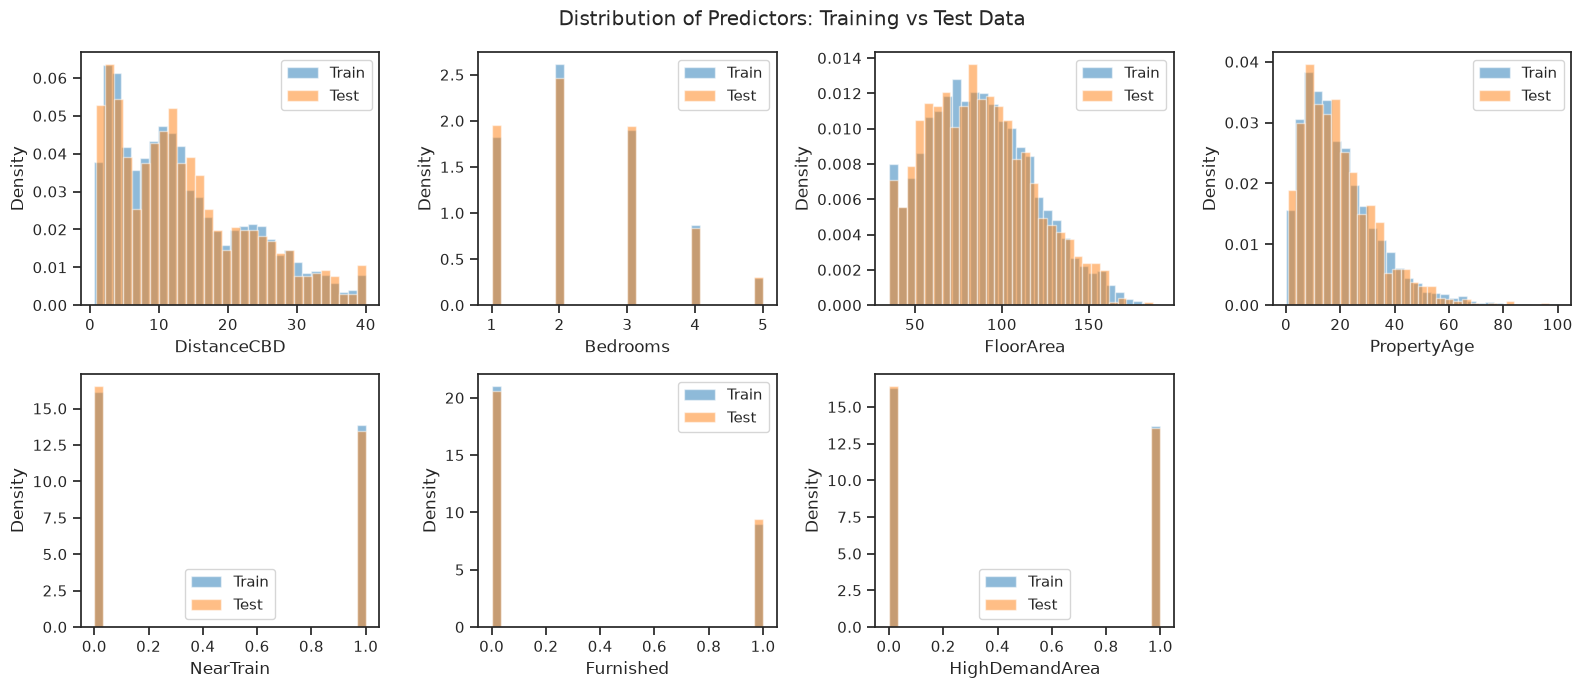

In [7]:
fig, ax = plt.subplots(2, 4, figsize=(16, 7))
ax = ax.flatten()

for i, var in enumerate(predictors):
    ax[i].hist(train[var], bins=30, density=True, alpha = 0.5, label = "Train")
    ax[i].hist(test[var], bins=30, density=True, alpha = 0.5, label = "Test")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Density")
    ax[i].legend()

ax[7].axis('off') # only 7 predictors, so the last panel is empty
fig.suptitle("Distribution of Predictors: Training vs Test Data")
plt.tight_layout()
plt.show()

### 2.5 Distribution of the response

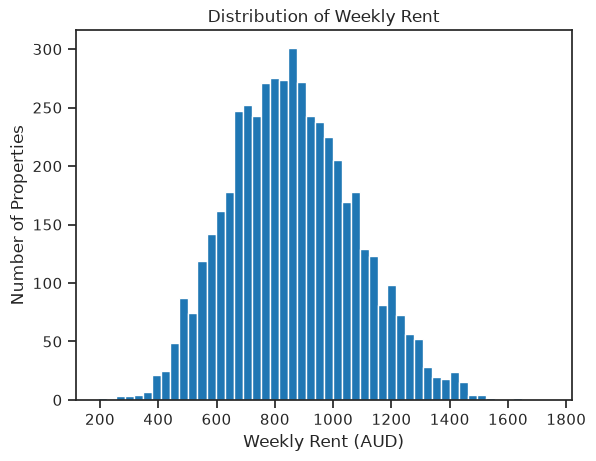

Mean: 860.6811, median: 849.0900, std: 215.4138, skewness: 0.2660


In [8]:
fig = plt.figure()

plt.hist(train[response], bins=50)
plt.xlabel("Weekly Rent (AUD)")
plt.ylabel("Number of Properties")
plt.title("Distribution of Weekly Rent")

plt.show()

print('Mean: {0:.4f}, median: {1:.4f}, std: {2:.4f}, skewness: {3:.4f}'.format(
    train[response].mean(), train[response].median(), train[response].std(), train[response].skew()))

### 2.6 Weekly rent vs continuous predictors

A straight line and a quadratic curve are fitted to each plot; if they differ clearly, the relationship is non-linear.

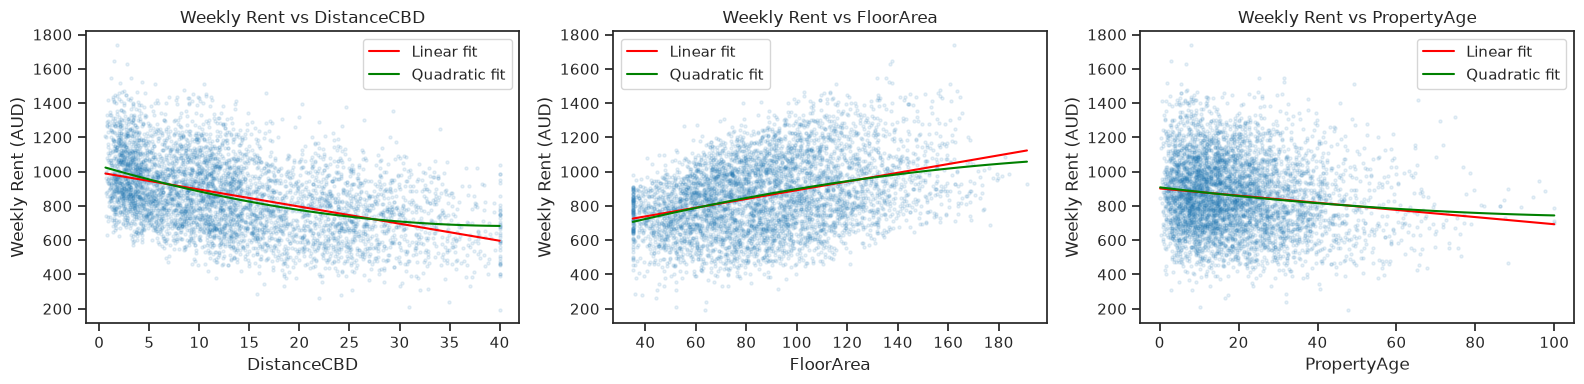

In [9]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# One row of three panels, one panel per continuous predictor
fig, ax = plt.subplots(1, 3, figsize=(16, 4))

for i, var in enumerate(continuous):
    x = train[[var]].values                    # predictor as a 2-D array (sklearn needs 2-D input)
    y = train[response]                        # weekly rent
    x_points = np.linspace(x.min(), x.max(), 100).reshape(-1, 1) # evenly spaced values to draw the curves

    # Straight line: rent = b0 + b1*x
    lin_reg = LinearRegression()
    lin_reg.fit(x, y)

    # Quadratic curve: rent = b0 + b1*x + b2*x^2
    poly_transformer = PolynomialFeatures(2)       # will create columns [1, x, x^2]
    poly_x = poly_transformer.fit_transform(x)     # the new 3-column data
    poly_reg = LinearRegression()
    poly_reg.fit(poly_x, y)

    ax[i].scatter(x, y, alpha = 0.1, s = 5)
    ax[i].plot(x_points, lin_reg.predict(x_points), color = "red", label = "Linear fit")
    ax[i].plot(x_points, poly_reg.predict(poly_transformer.transform(x_points)), color = "green", label = "Quadratic fit")
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title("Weekly Rent vs " + var)
    ax[i].legend()

plt.tight_layout()
plt.show()

### 2.7 Weekly rent by `Bedrooms` and by the binary predictors

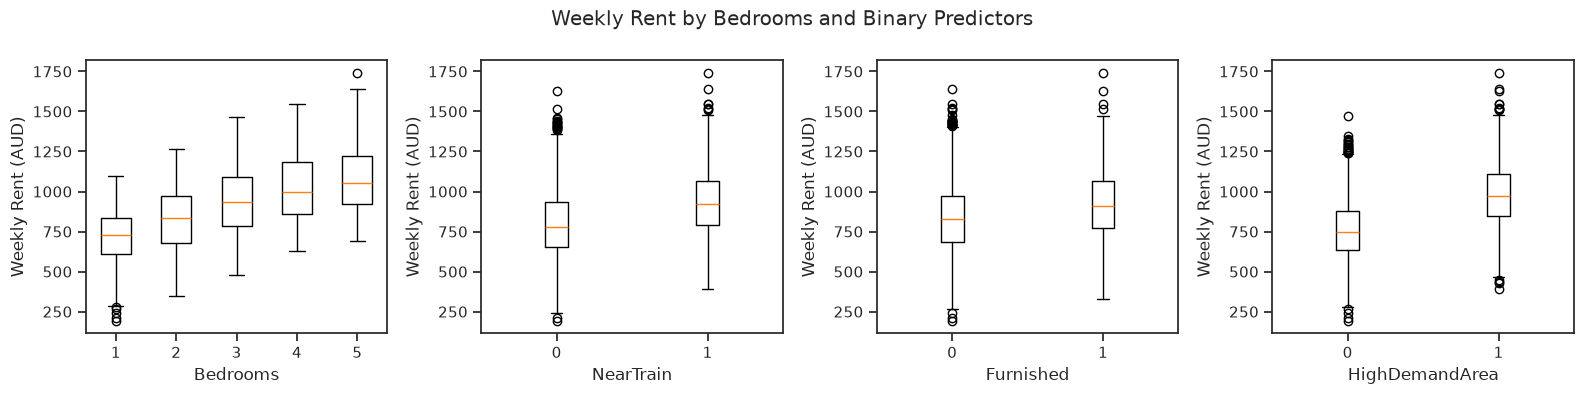

In [10]:
# NOTE: not from tutorial — reason: box plots are requested for this EDA; the tutorials compare groups with overlaid histograms (W1)
group_vars = ['Bedrooms'] + binary     # join two lists: ['Bedrooms', 'NearTrain', 'Furnished', 'HighDemandArea']

# One row of four panels, one per grouping variable
fig, ax = plt.subplots(1, 4, figsize=(16, 4))

for i, var in enumerate(group_vars):
    levels = sorted(train[var].unique())     # the distinct values of this variable, e.g. [0, 1]

    # Collect the rents of each group into a list
    groups = []                              # start with an empty list
    for level in levels:
        rent_in_group = train.loc[train[var] == level, response]   # rents of properties in this group
        groups.append(rent_in_group)                               # add them to the list

    ax[i].boxplot(groups)                    # one box per group
    ax[i].set_xticklabels(levels)            # label each box with its group value (default would be 1, 2, ...)
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")

fig.suptitle("Weekly Rent by Bedrooms and Binary Predictors")   # title for the whole figure
plt.tight_layout()                           # adjust spacing so labels do not overlap
plt.show()

In [11]:
# For each grouping variable, show how many properties are in each group and their mean rent
for var in group_vars:
    # groupby(var): split the data into groups by the value of var (e.g. NearTrain = 0 and 1)
    # [response]: look at weekly rent only
    # agg(['count', 'mean']): for each group, count the properties and compute the mean rent
    # '\n': print a blank line between the tables
    print(train.groupby(var)[response].agg(['count', 'mean']).round(4), '\n')

          count       mean
Bedrooms                  
1          1213   717.9369
2          1741   823.7616
3          1264   938.8978
4           583  1020.8464
5           199  1087.7315 

           count      mean
NearTrain                 
0           2690  797.2066
1           2310  934.5973 

           count      mean
Furnished                 
0           3501  835.9160
1           1499  918.5214 

                count      mean
HighDemandArea                 
0                2719  759.2359
1                2281  981.6058 



**Differences in mean rent.** For each binary predictor, subtract the mean rent of group 0 from group 1; for `Bedrooms`,
show how much the mean rent changes with each extra bedroom.

In [12]:
# Mean rent of group 1 minus group 0 (raw difference, other predictors not held fixed)
for var in binary:
    means = train.groupby(var)[response].mean()   # index 0 and 1
    print('{}: {:.4f}'.format(var, means[1] - means[0]))

# Change in mean rent from one bedroom count to the next; diff() subtracts the previous row
bedroom_means = train.groupby('Bedrooms')[response].mean()
print('\nExtra rent for each additional bedroom:')
print(bedroom_means.diff().round(4))

NearTrain: 137.3907
Furnished: 82.6055
HighDemandArea: 222.3699

Extra rent for each additional bedroom:
Bedrooms
1         NaN
2    105.8247
3    115.1362
4     81.9486
5     66.8850
Name: WeeklyRent, dtype: float64


**Summary.** Rent rises with bedrooms (717.9369 to 1087.7315 AUD), but the step shrinks after three bedrooms.
High-demand areas (+222.3699 AUD), train access (+137.3907) and furnishing (+82.6055) have higher rent (raw differences,
not controlling for other predictors).

### 2.8 Correlations

Correlations rank predictors by their linear association with rent and reveal multicollinearity.

In [13]:
correlations = train.corr()
correlations.round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea
WeeklyRent,1.0000,-0.4421,0.5062,0.3567,-0.1375,0.3180,0.1757,0.5142
DistanceCBD,-0.4421,1.0000,0.3319,0.5286,0.0163,-0.1780,-0.1300,-0.3727
Bedrooms,0.5062,0.3319,1.0000,0.8821,-0.0009,-0.0589,-0.1297,-0.1276
FloorArea,0.3567,0.5286,0.8821,1.0000,-0.0079,-0.0882,-0.1339,-0.1947
PropertyAge,-0.1375,0.0163,-0.0009,-0.0079,1.0000,0.0186,-0.0598,-0.0104
NearTrain,0.3180,-0.1780,-0.0589,-0.0882,0.0186,1.0000,0.0039,0.2385
Furnished,0.1757,-0.1300,-0.1297,-0.1339,-0.0598,0.0039,1.0000,0.0273
HighDemandArea,0.5142,-0.3727,-0.1276,-0.1947,-0.0104,0.2385,0.0273,1.0000


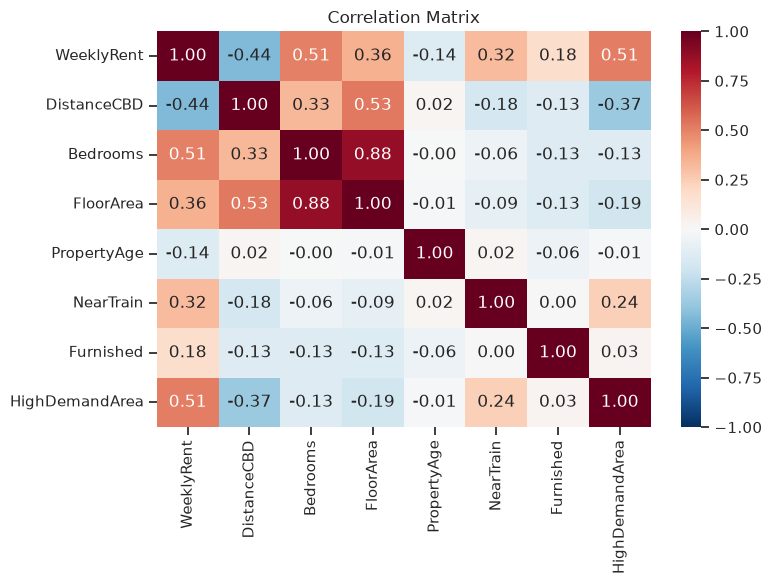

In [14]:
# NOTE: not from tutorial — reason: a heatmap displays the correlation table above more clearly (seaborn is used in W2)
fig = plt.figure(figsize=(8, 6))

sns.heatmap(correlations, annot = True, fmt = ".2f", cmap = "RdBu_r", vmin = -1, vmax = 1)
plt.title("Correlation Matrix")
plt.tight_layout()

plt.show()

Correlation of each predictor with rent, sorted (as in Tutorial 5):

In [15]:
# Correlation of each predictor with rent (the WeeklyRent column), without rent itself
rent_corr = correlations[response].drop(response)
# Sort from the largest to the smallest value
rent_corr = rent_corr.sort_values(ascending = False)
rent_corr.round(4)

HighDemandArea    0.5142
Bedrooms          0.5062
FloorArea         0.3567
NearTrain         0.3180
Furnished         0.1757
PropertyAge      -0.1375
DistanceCBD      -0.4421
Name: WeeklyRent, dtype: float64

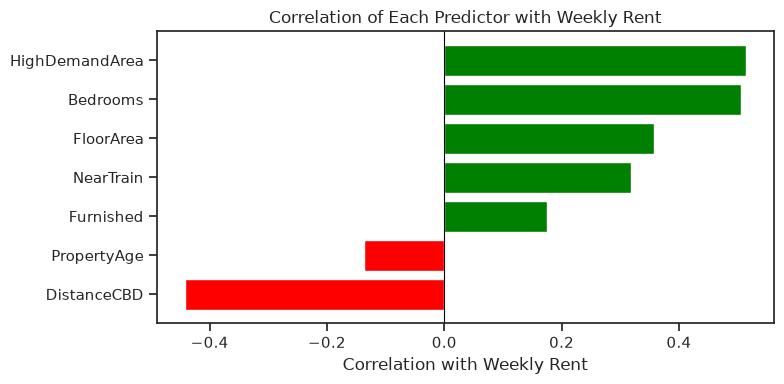

In [16]:
# NOTE: not from tutorial — reason: a bar chart shows the ranking of the correlations above more clearly
fig = plt.figure(figsize=(8, 4))

# One horizontal bar per predictor; green = positive, red = negative correlation
colors = ["green" if value > 0 else "red" for value in rent_corr]
plt.barh(rent_corr.index, rent_corr.values, color = colors)
plt.axvline(0, color = "black", linewidth = 0.8)   # vertical line at zero
plt.gca().invert_yaxis()                            # put the strongest positive correlation at the top
plt.xlabel("Correlation with Weekly Rent")
plt.title("Correlation of Each Predictor with Weekly Rent")
plt.tight_layout()

plt.show()

**Summary.** `HighDemandArea` and `Bedrooms` are most correlated with rent (0.51), then `DistanceCBD` (-0.44).
`Bedrooms` and `FloorArea` are highly correlated (0.88).

### 2.9 Interaction exploration

An interaction means the effect of one predictor depends on another (Lecture 2). For each pair, a separate line is
fitted in each group: non-parallel lines suggest an interaction.

DistanceCBD slope when HighDemandArea = 0: -6.5278
DistanceCBD slope when HighDemandArea = 1: -6.6099
DistanceCBD slope when NearTrain = 0: -9.7187


DistanceCBD slope when NearTrain = 1: -7.8084
FloorArea slope when HighDemandArea = 0: 2.7801
FloorArea slope when HighDemandArea = 1: 4.2642
Bedrooms slope when HighDemandArea = 0: 97.9606
Bedrooms slope when HighDemandArea = 1: 138.8588


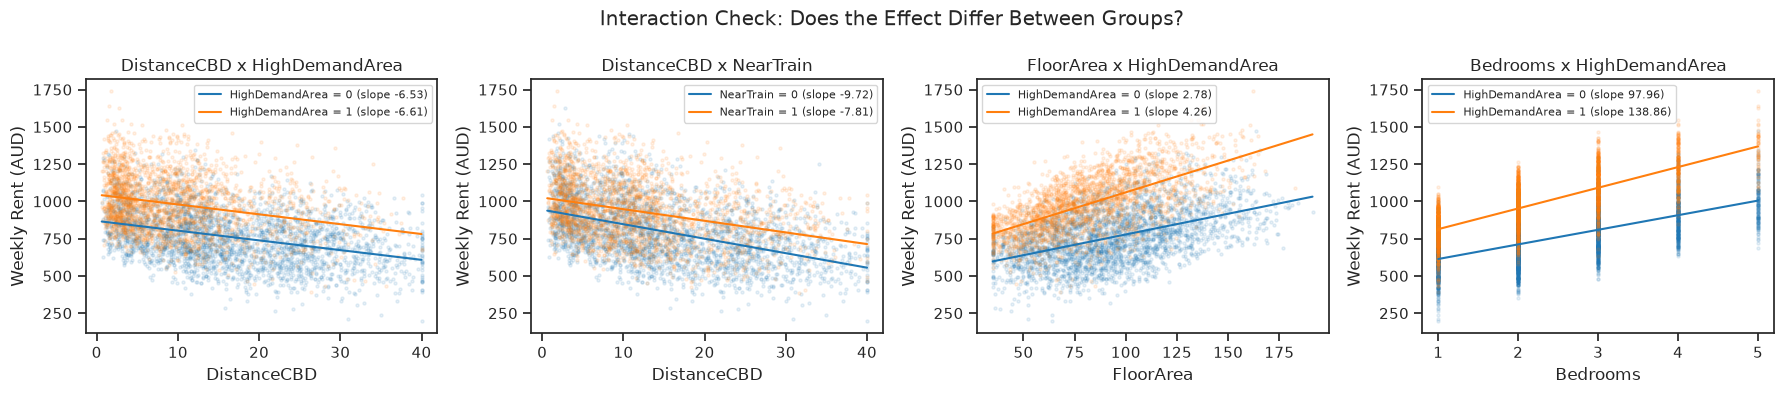

In [17]:
# Pairs to check: (predictor on the x-axis, binary variable used to split the data)
pairs = [('DistanceCBD', 'HighDemandArea'), ('DistanceCBD', 'NearTrain'),
         ('FloorArea', 'HighDemandArea'), ('Bedrooms', 'HighDemandArea')]

fig, ax = plt.subplots(1, 4, figsize=(18, 4))     # one row of four panels

for i, (var, group) in enumerate(pairs):
    # Two groups: level 0 in blue, level 1 in orange (zip pairs each level with a colour)
    for level, color in zip([0, 1], ["#1F77B4", "#FF7F0E"]):
        subset = train[train[group] == level]                      # properties in this group only
        # Simple OLS within the group: rent = b0 + b1 * var
        x_with_intercept = sm.add_constant(subset[[var]], prepend=True)
        est = sm.OLS(subset[response], x_with_intercept).fit()
        print('{} slope when {} = {}: {:.4f}'.format(var, group, level, est.params.iloc[1]))   # b1 to 4 d.p.
        x_points = np.linspace(train[var].min(), train[var].max(), 100)   # points to draw the line

        ax[i].scatter(subset[var], subset[response], alpha = 0.1, s = 5, color = color)
        # Fitted line b0 + b1 * x; the legend shows the slope b1 of this group
        ax[i].plot(x_points, est.params.iloc[0] + est.params.iloc[1] * x_points, color = color,
                   label = "{} = {} (slope {:.2f})".format(group, level, est.params.iloc[1]))
    ax[i].set_xlabel(var)
    ax[i].set_ylabel("Weekly Rent (AUD)")
    ax[i].set_title(var + " x " + group)           # which pair this panel checks
    ax[i].legend(fontsize = 8)                     # small legend so it does not cover the points

# Different slopes (non-parallel lines) suggest an interaction
fig.suptitle("Interaction Check: Does the Effect Differ Between Groups?")
plt.tight_layout()
plt.show()

**Summary.** The lines for `Bedrooms` (138.8588 vs 97.9606 AUD per bedroom) and `FloorArea` (4.2642 vs 2.7801 AUD
per m²) are not parallel, suggesting interactions with `HighDemandArea`. The distance lines are almost parallel across
`HighDemandArea`, but the distance slope is flatter near a train station. These slopes do not control for other
predictors, so interaction terms are tested in Section 3.

### 2.10 Baseline OLS model and outlier check

In [18]:
# Baseline OLS: rent on the seven predictors (linear terms only), as in Tutorial 7
x_with_intercept = sm.add_constant(train[predictors], prepend=True)   # add a column of ones for the intercept
ols = sm.OLS(train[response], x_with_intercept)                       # set up the model: y = rent, X = predictors
est = ols.fit()                                                       # estimate the coefficients by least squares
print(est.summary())                                                  # coefficients, p-values, R-squared, AIC, BIC
print('R-squared: {:.4f}'.format(est.rsquared))                       # R-squared to 4 d.p. (the summary shows 3)

                            OLS Regression Results                            
Dep. Variable:             WeeklyRent   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                     9345.
Date:                Tue, 29 Sep 2026   Prob (F-statistic):               0.00
Time:                        06:40:56   Log-Likelihood:                -27341.
No. Observations:                5000   AIC:                         5.470e+04
Df Residuals:                    4992   BIC:                         5.475e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            481.9479      3.335    144.

**Result.** R² = 0.9291 and all seven predictors are significant (p < 0.001).

In [19]:
# Residual = actual rent - fitted rent, one value per property
residuals = est.resid

**Outlier check.** Standardised residual = residual / estimated error standard deviation.
Under normal errors about 0.27% of observations should exceed ±3.

In [20]:
from scipy import stats

# Estimated standard deviation of the errors (square root of the residual mean squared error)
sigma_hat = np.sqrt(est.mse_resid)
# Standardised residual = residual / sigma_hat
std_resid = residuals / sigma_hat

# Flag observations more than 3 standard deviations away from their fitted value
outliers = np.abs(std_resid) > 3
# Number expected by chance if the errors are normal: n x P(|Z| > 3)
expected = len(train) * 2 * (1 - stats.norm.cdf(3))

print('Observations with |standardised residual| > 3: {}'.format(outliers.sum()))
print('Expected by chance under normal errors:        {0:.4f}'.format(expected))
print('Largest |standardised residual|:              {0:.4f}'.format(np.abs(std_resid).max()))

Observations with |standardised residual| > 3: 17
Expected by chance under normal errors:        13.4990
Largest |standardised residual|:              4.2356


In [21]:
# Show the flagged observations, sorted by their standardised residual
outlier_rows = train[outliers].copy()
outlier_rows['std_resid'] = std_resid[outliers]
outlier_rows.sort_values('std_resid').round(4)

,WeeklyRent,DistanceCBD,Bedrooms,FloorArea,PropertyAge,NearTrain,Furnished,HighDemandArea,std_resid
56,779.24,30.82,5,174.3,15.6,0,0,0,-3.3569
2503,606.96,9.19,1,47.5,13.9,1,0,1,-3.3540
3018,683.11,11.67,1,53.1,14.2,1,1,1,-3.2787
2046,1054.19,14.51,5,161.1,14.7,1,0,0,-3.1635
908,1023.68,8.06,5,155.4,29.2,0,0,0,-3.1113
48,847.13,22.18,5,153.3,17.6,0,0,0,-3.0711
1300,689.50,33.42,5,176.7,63.3,0,0,0,-3.0137
4635,1273.12,2.16,3,60.6,19.4,0,1,1,3.0014
3653,926.79,34.22,3,116.5,20.1,1,1,0,3.1136
1332,598.04,35.68,1,90.0,6.5,1,0,0,3.1598


**Capped values.** `DistanceCBD` has a maximum of exactly 40 and `FloorArea` a minimum of exactly 35 (summary statistics in 2.3
and 2.4). Count how many properties sit exactly at these values; many ties at the boundary suggest the variable is capped.

In [22]:
# Number of properties exactly at the boundary value (True counts as 1)
print('DistanceCBD = 40 (train): {}'.format((train['DistanceCBD'] == 40).sum()))
print('DistanceCBD = 40 (test):  {}'.format((test['DistanceCBD'] == 40).sum()))
print('FloorArea = 35 (train):   {}'.format((train['FloorArea'] == 35).sum()))

DistanceCBD = 40 (train): 43
DistanceCBD = 40 (test):  12
FloorArea = 35 (train):   106


**Patterns in the flagged observations.** Count how many of the flagged properties are far from the CBD and underpredicted
(positive residual), and how many are five-bedroom properties that are overpredicted (negative residual).

In [23]:
# Far from the CBD (30 km or more) and rent underpredicted (actual > fitted, so residual > 0)
far_under = (outlier_rows['DistanceCBD'] >= 30) & (outlier_rows['std_resid'] > 0)
# Five bedrooms and rent overpredicted (actual < fitted, so residual < 0)
five_over = (outlier_rows['Bedrooms'] == 5) & (outlier_rows['std_resid'] < 0)

print('Far (>= 30 km) and underpredicted: {}'.format(far_under.sum()))
print('  of which at the 40 km cap:       {}'.format((outlier_rows['DistanceCBD'][far_under] == 40).sum()))
print('Five bedrooms and overpredicted:   {}'.format(five_over.sum()))

Far (>= 30 km) and underpredicted: 7
  of which at the 40 km cap:       3
Five bedrooms and overpredicted:   5


**Result.** 17 observations exceed ±3, slightly more than the 13.4990 expected by chance (largest 4.2356). Twelve of them
follow two patterns: 7 properties at least 30 km from the CBD are underpredicted (3 at the 40 km cap), and 5 five-bedroom
properties are overpredicted. The linear model misses these non-linear effects; they are not data errors, so all
observations are kept. `DistanceCBD` (40 km) and `FloorArea` (35 m²) appear to be capped.

### 2.11 Summary of EDA findings

- No missing values or duplicates; test covariates match the training covariates.
- No data errors; the 17 large residuals are kept.
- `WeeklyRent` is roughly symmetric (skewness 0.27), so it is not transformed.
- Rent is non-linear in `DistanceCBD` and `FloorArea`.
- `Bedrooms` and `FloorArea` are highly correlated (0.88).
- `Bedrooms` and `FloorArea` may interact with `HighDemandArea`.
- The linear OLS already has R² = 0.929.

## 3. Modelling and model selection

Each model is fitted and then evaluated with **10-fold cross-validation** (CV) on the same folds (Tutorials 5–6).
The final model has the smallest CV MSE; if models are within one standard error, the simpler one is chosen.
Ridge, lasso, elastic net and KNN standardise the predictors inside each fold (`Pipeline`) to avoid data leakage.

### 3.1 Cross-validation set-up

The same 10 folds (`kf`) are used for every model, so the CV errors can be compared fairly (Tutorial 6).
`cv_mse(model, X)` runs the 10-fold CV for one model and returns the CV MSE and its standard error (SE).

In [24]:
from sklearn.model_selection import KFold, cross_val_score

y = train[response]

# 10-fold CV with shuffling; random_state fixes the folds, so every model uses the same folds
kf = KFold(10, shuffle=True, random_state=1)

def cv_mse(model, X):
    # fit on 9 folds (4500 rows), predict the held-out fold (500 rows), 10 times
    scores = cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
    fold_mse = -scores                                      # scikit-learn returns negative MSE, so change the sign
    mean_mse = np.mean(fold_mse)                            # CV MSE = average of the 10 fold MSEs
    se = np.std(fold_mse, ddof=1) / np.sqrt(len(fold_mse))  # standard error = sample std of fold MSEs / sqrt(10)
    return mean_mse, se                                     # returns two numbers

results = []   # one dictionary per model, turned into a table at the end (as in Tutorial 6)

### 3.2 Baseline models: M0 and M1

- **M0:** predicts the average rent for every property.
- **M1:** OLS with the seven original predictors.

In [25]:
# M0: predict the average rent of the training folds (manual loop over the same folds)
fold_mse = []
for train_index, valid_index in kf.split(train):
    prediction = y.iloc[train_index].mean()                              # mean rent of the training folds
    fold_mse.append(np.mean((y.iloc[valid_index] - prediction) ** 2))    # MSE on the validation fold

m0_mse = np.mean(fold_mse)
m0_se = np.std(fold_mse, ddof=1) / np.sqrt(len(fold_mse))
results.append({'Model': 'M0: Null model', 'CV MSE': m0_mse, 'SE': m0_se})
print('M0 prediction on all training data: {0:.4f} AUD'.format(y.mean()))
print('M0 CV MSE: {0:.4f} (SE {1:.4f})'.format(m0_mse, m0_se))

M0 prediction on all training data: 860.6811 AUD
M0 CV MSE: 46409.4061 (SE 842.9485)


In [26]:
from sklearn.linear_model import LinearRegression

# M1: OLS with the seven original predictors
X_m1 = train[predictors]          # 5000 x 7 table of predictors (y = WeeklyRent, defined in 3.1)

# Create the linear regression object (empty model, nothing learned yet)
lin_reg = LinearRegression()

# Estimate the coefficients by least squares on all 5000 training rows (only to look at them)
lin_reg.fit(X_m1, y)

# Print the fitted equation: intercept and one slope per predictor
print('Intercept: {0:.4f}'.format(lin_reg.intercept_))
for name, coef in zip(predictors, lin_reg.coef_):        # pair each predictor name with its coefficient
    print('{0}: {1:.4f}'.format(name, coef))

Intercept: 481.9479
DistanceCBD: -13.6208
Bedrooms: 83.0277
FloorArea: 2.9902
PropertyAge: -1.7023
NearTrain: 79.6334
Furnished: 89.3712
HighDemandArea: 161.6766


The CV MSE of M1 is computed with `cv_mse` on the same folds as M0.

In [27]:
# 10-fold CV of M1 (cv_mse is defined in 3.1)
m1_mse, m1_se = cv_mse(lin_reg, X_m1)
results.append({'Model': 'M1: OLS, 7 linear terms', 'CV MSE': m1_mse, 'SE': m1_se})   # store for the comparison table
print('M1 CV MSE: {0:.4f} (SE {1:.4f})'.format(m1_mse, m1_se))

M1 CV MSE: 3302.3821 (SE 29.6067)


**Result.** M1 reduces the CV MSE from about 46,400 (M0) to about 3,300.

### 3.3 M2: best subset selection

Are all seven predictors needed? Following Lectures 4–5, all 127 non-empty subsets of the seven predictors are fitted by OLS
(128 including the null model M0). Within each size, the subset with the smallest RSS is kept. The best models of different sizes
are then compared by 10-fold CV, because RSS always decreases as predictors are added.

In [28]:
# NOTE: not from tutorial — reason: itertools.combinations lists all subsets of a given size for best subset selection (Lectures 4-5)
import itertools

best_subsets = []                                         # best model of each size
for k in range(1, len(predictors) + 1):                   # k = 1, 2, ..., 7 predictors
    best_rss = np.inf                                     # reset for each size k: any real RSS beats infinity
    for subset in itertools.combinations(predictors, k):  # try every model with exactly k predictors (e.g. 21 when k = 2)
        x_with_intercept = sm.add_constant(train[list(subset)], prepend=True)   # these k columns + intercept (Tutorial 7)
        est = sm.OLS(y, x_with_intercept).fit()                                 # fit OLS by least squares
        if est.ssr < best_rss:                            # ssr = residual sum of squares (RSS); smaller than the best so far?
            best_rss = est.ssr                            # keep the new best RSS
            best_subset = list(subset)                    # and its predictors

    mse, se = cv_mse(LinearRegression(), train[best_subset])   # CV MSE of the best model of this size
    best_subsets.append({'Size': k, 'Predictors': best_subset, 'RSS': best_rss, 'CV MSE': mse, 'SE': se})

best_subsets = pd.DataFrame(best_subsets).set_index('Size')   # one row per model size
best_subsets.round(4)

,Predictors,RSS,CV MSE,SE
Size,,,,
1,[HighDemandArea],1.706329e+08,34146.8768,627.9167
2,"[DistanceCBD, FloorArea]",7.442294e+07,14900.7981,211.7488
3,"[DistanceCBD, FloorArea, HighDemandArea]",4.188526e+07,8388.2431,107.5607
4,"[DistanceCBD, Bedrooms, Furnished, HighDemandA...",3.340712e+07,6695.8734,98.2287
5,"[DistanceCBD, Bedrooms, NearTrain, Furnished, ...",2.608617e+07,5233.3094,107.4317
6,"[DistanceCBD, Bedrooms, FloorArea, NearTrain, ...",1.934817e+07,3882.9493,51.8272
7,"[DistanceCBD, Bedrooms, FloorArea, PropertyAge...",1.644736e+07,3302.3821,29.6067


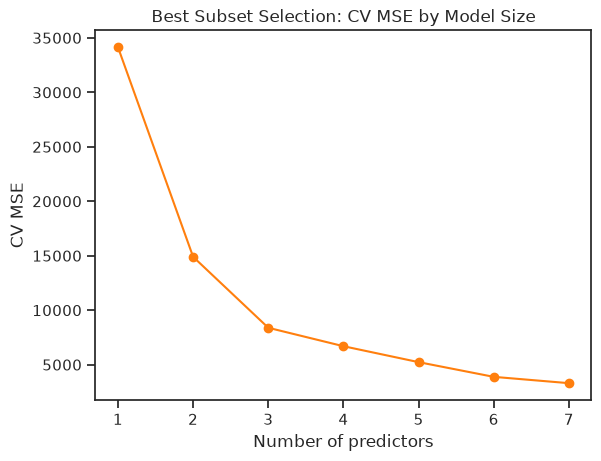

Best size: 7 predictors
Predictors: ['DistanceCBD', 'Bedrooms', 'FloorArea', 'PropertyAge', 'NearTrain', 'Furnished', 'HighDemandArea']
M2 CV MSE: 3302.3821 (SE 29.6067)


In [29]:
# Plot CV MSE against model size: RSS always falls with more predictors, CV MSE does not have to
fig = plt.figure()
plt.plot(best_subsets.index, best_subsets['CV MSE'], marker = 'o', color = '#FF7F0E')
plt.xlabel('Number of predictors')
plt.ylabel('CV MSE')
plt.title('Best Subset Selection: CV MSE by Model Size')
plt.show()

best_size = best_subsets['CV MSE'].idxmin()                # size with the smallest CV MSE
m2_mse = best_subsets.loc[best_size, 'CV MSE']             # CV MSE of M2
m2_se = best_subsets.loc[best_size, 'SE']                  # its standard error
results.append({'Model': 'M2: Best subset ({} predictors)'.format(best_size), 'CV MSE': m2_mse, 'SE': m2_se})   # store for the comparison table
print('Best size: {} predictors'.format(best_size))
print('Predictors:', best_subsets.loc[best_size, 'Predictors'])
print('M2 CV MSE: {0:.4f} (SE {1:.4f})'.format(m2_mse, m2_se))

**Result.** CV MSE falls at every size, so the best subset contains all seven predictors and M2 equals M1. The best single predictor
(`HighDemandArea`) is not in the best two-predictor model (`DistanceCBD`, `FloorArea`), which shows why stepwise selection may miss
the best subset. Linear terms alone cannot capture the curvature found in the EDA.

### 3.4 Expanded features

`make_features(df)` adds 4 squared terms and 21 pairwise interactions to the seven predictors (32 columns).
The same function is applied to the test data later.

In [30]:
def make_features(df):
    # Start from the seven original predictors
    features = df[predictors].copy()

    # Squared terms (not for 0/1 variables, since 0^2 = 0 and 1^2 = 1)
    for var in ['DistanceCBD', 'FloorArea', 'Bedrooms', 'PropertyAge']:
        features[var + '_SQ'] = features[var] ** 2

    # All pairwise interactions: product of two predictors
    for j in range(len(predictors)):
        for k in range(j + 1, len(predictors)):     # each pair once, never a predictor with itself
            var1 = predictors[j]
            var2 = predictors[k]
            features[var1 + '_x_' + var2] = features[var1] * features[var2]

    return features

X_all = make_features(train)                                        # 32 columns
extra_terms = [c for c in X_all.columns if c not in predictors]     # the 25 squared and interaction terms
print('Number of columns: {}'.format(X_all.shape[1]))

Number of columns: 32


### 3.5 M3: EDA-driven OLS

The seven predictors plus the terms suggested by the EDA:

| Term | EDA evidence |
|---|---|
| `DistanceCBD_SQ`, `FloorArea_SQ` | curvature (Section 2.6) |
| `Bedrooms_SQ` | smaller increase per extra bedroom (Section 2.7) |
| `Bedrooms_x_HighDemandArea`, `FloorArea_x_HighDemandArea`, `DistanceCBD_x_NearTrain` | different slopes (Section 2.9) |

In [31]:
eda_terms = ['DistanceCBD_SQ', 'FloorArea_SQ', 'Bedrooms_SQ',
             'Bedrooms_x_HighDemandArea', 'FloorArea_x_HighDemandArea', 'DistanceCBD_x_NearTrain']

# Fit on all training data to look at the coefficients and p-values of the added terms (as in Tutorial 7)
x_with_intercept = sm.add_constant(X_all[predictors + eda_terms], prepend=True)
m3 = sm.OLS(y, x_with_intercept).fit()
print(pd.DataFrame({'coef': m3.params[eda_terms], 'p-value': m3.pvalues[eda_terms]}).round(4))

# CV MSE of the EDA-driven model
mse, se = cv_mse(LinearRegression(), X_all[predictors + eda_terms])
results.append({'Model': 'M3: EDA-driven OLS, 6 extra terms', 'CV MSE': mse, 'SE': se})
print('\nM3 CV MSE: {0:.4f} (SE {1:.4f})'.format(mse, se))

                               coef  p-value
DistanceCBD_SQ               0.2951   0.0000
FloorArea_SQ                -0.0124   0.0000
Bedrooms_SQ                 -0.3575   0.6078
Bedrooms_x_HighDemandArea   32.7640   0.0000
FloorArea_x_HighDemandArea  -0.0662   0.4913
DistanceCBD_x_NearTrain      2.7860   0.0000

M3 CV MSE: 2075.4951 (SE 27.7922)


**Result.** CV MSE falls from 3302 (M1) to about 2075, so the EDA terms help. `Bedrooms_SQ` and `FloorArea_x_HighDemandArea` are not
significant, because `Bedrooms` and `FloorArea` are highly correlated; stepwise selection is used to choose terms systematically.

### 3.6 M4: forward stepwise selection

Starting from the seven predictors, add the squared or interaction term with the smallest RSS at each step (Lectures 4–5).
The models with the smallest AIC and BIC on this path are evaluated by CV. AIC and BIC are computed as in Tutorial 6:
$AIC = n\log(\hat{\sigma}^2) + 2d$ and $BIC = n\log(\hat{\sigma}^2) + \log(n)d$, where $\hat{\sigma}^2 = RSS/n$ and $d$ is the number of
parameters (intercept, slopes and error variance).

In [32]:
# NOTE: not from tutorial — reason: Tutorial 7 removes predictors by hand; this loop automates forward stepwise selection (Lectures 4-5)
def fit_ols(terms):
    # OLS with the seven main effects plus the given extra terms (statsmodels, as in Tutorial 7)
    x_with_intercept = sm.add_constant(X_all[predictors + terms], prepend=True)
    return sm.OLS(y, x_with_intercept).fit()

n = len(y)                                 # number of observations (5000)

def aic_bic(est, number_of_parameters):
    # AIC and BIC as in Tutorial 6 (sigma2_hat = RSS / n, the same as mean_squared_error(y, y_pred))
    sigma2_hat = est.ssr / n
    aic_value = n * np.log(sigma2_hat) + 2 * number_of_parameters
    bic_value = n * np.log(sigma2_hat) + np.log(n) * number_of_parameters
    return aic_value, bic_value

forward_path = []                          # one row per step of the path
current = []                               # extra terms in the current model (start: none = M1)
remaining = list(extra_terms)              # the 25 candidate terms not yet added
est = fit_ols(current)                     # step 0: the seven main effects only
aic_value, bic_value = aic_bic(est, len(predictors) + len(current) + 2)   # parameters: intercept + slopes + error variance
forward_path.append({'Extra terms': 0, 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

while len(remaining) > 0:                  # repeat until every candidate term has been added
    best_rss = np.inf                      # reset for each step: any real RSS beats infinity
    for term in remaining:                 # try adding each remaining term, one at a time
        est = fit_ols(current + [term])
        if est.ssr < best_rss:             # ssr = RSS; keep the term that lowers RSS the most
            best_rss = est.ssr
            best_term = term
    current.append(best_term)              # add the winning term to the model
    remaining.remove(best_term)            # and take it out of the candidate list
    est = fit_ols(current)                 # refit the new model
    aic_value, bic_value = aic_bic(est, len(predictors) + len(current) + 2)   # AIC and BIC of the new model
    forward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

forward_path = pd.DataFrame(forward_path).set_index('Extra terms')

In [33]:
# Pick the models with the smallest AIC and BIC on the path, then evaluate them by CV
m4_summary = []                                                         # one row per criterion, shown as a small table
for criterion in ['AIC', 'BIC']:
    best_step = forward_path[criterion].idxmin()                        # step with the smallest AIC (or BIC)
    terms = forward_path.loc[best_step, 'Terms']                        # extra terms of that step
    mse, se = cv_mse(LinearRegression(), X_all[predictors + terms])     # 10-fold CV of that model
    results.append({'Model': 'M4: Forward stepwise ({}), {} extra terms'.format(criterion, len(terms)),
                    'CV MSE': mse, 'SE': se})                             # store for the comparison table
    m4_summary.append({'Criterion': criterion, 'Extra terms': len(terms), 'CV MSE': mse, 'SE': se})

print(pd.DataFrame(m4_summary).set_index('Criterion').round(4))

# Terms in the order they were added; BIC stops one step earlier than AIC
aic_terms = forward_path.loc[forward_path['AIC'].idxmin(), 'Terms']
bic_terms = forward_path.loc[forward_path['BIC'].idxmin(), 'Terms']
print('\nTerms added (in order):')
for i, term in enumerate(aic_terms):                                    # i = 0, 1, 2, ... ; term = name
    if term in bic_terms:
        print('{}. {}'.format(i + 1, term))
    else:
        print('{}. {}   (AIC only)'.format(i + 1, term))

           Extra terms     CV MSE       SE
Criterion                                 
AIC                  7  2005.8861  26.4687
BIC                  6  2005.6203  27.4624

Terms added (in order):
1. DistanceCBD_SQ
2. Bedrooms_x_HighDemandArea
3. FloorArea_SQ
4. DistanceCBD_x_NearTrain
5. Bedrooms_x_Furnished
6. PropertyAge_SQ
7. Furnished_x_HighDemandArea   (AIC only)


**Result.** BIC keeps 6 extra terms and AIC keeps 7. Their CV MSEs differ by less than 1 SE, so the simpler BIC model is preferred.

### 3.7 M5: backward stepwise selection

Forward selection may miss a good combination, because a term, once added, is never removed. Backward selection checks
this from the opposite direction: start with the biggest model (the seven predictors plus all 25 extra terms), then drop
the least useful term one at a time, i.e. the term whose removal increases the RSS the least (Lectures 4–5). The seven
predictors are always kept. As in M4, AIC and BIC choose where to stop, and the chosen models are evaluated by CV.

In [34]:
# NOTE: not from tutorial — reason: automates the backward elimination done by hand in Tutorial 7 (Lectures 4-5)
backward_path = []                    # one row per step of the path (25 extra terms down to 0)
removed = []                          # extra terms in the order they are removed
current = list(extra_terms)           # start with all 25 extra terms (the biggest model)
est = fit_ols(current)
aic_value, bic_value = aic_bic(est, len(predictors) + len(current) + 2)   # parameters: intercept + slopes + error variance
backward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

while len(current) > 0:               # repeat until every extra term has been removed
    best_rss = np.inf                 # reset for each step: any real RSS beats infinity
    for term in current:              # TRY: remove each term, one at a time
        reduced = [t for t in current if t != term]   # current terms without this one
        est = fit_ols(reduced)
        if est.ssr < best_rss:        # smallest RSS after removal = the model loses least = least useful term
            best_rss = est.ssr
            worst_term = term
    current.remove(worst_term)        # REMOVE: drop the least useful term (it never comes back)
    removed.append(worst_term)        # remember the removal order
    est = fit_ols(current)            # refit the smaller model
    aic_value, bic_value = aic_bic(est, len(predictors) + len(current) + 2)   # AIC and BIC (Tutorial 6 formula)
    backward_path.append({'Extra terms': len(current), 'Terms': list(current), 'AIC': aic_value, 'BIC': bic_value})

backward_path = pd.DataFrame(backward_path).set_index('Extra terms')   # 26 rows; row name = number of extra terms left

In [35]:
# Pick the models with the smallest AIC and BIC on the path, then evaluate them by CV
m5_summary = []                                                         # one row per criterion, shown as a small table
for criterion in ['AIC', 'BIC']:
    best_step = backward_path[criterion].idxmin()                       # number of extra terms left at the smallest AIC (or BIC)
    terms = backward_path.loc[best_step, 'Terms']                       # extra terms still in that model
    mse, se = cv_mse(LinearRegression(), X_all[predictors + terms])     # 10-fold CV of that model
    results.append({'Model': 'M5: Backward stepwise ({}), {} extra terms'.format(criterion, len(terms)),
                    'CV MSE': mse, 'SE': se})                             # store for the comparison table
    m5_summary.append({'Criterion': criterion, 'Extra terms': len(terms), 'CV MSE': mse, 'SE': se})

print(pd.DataFrame(m5_summary).set_index('Criterion').round(4))

aic_terms = backward_path.loc[backward_path['AIC'].idxmin(), 'Terms']
bic_terms = backward_path.loc[backward_path['BIC'].idxmin(), 'Terms']

# Terms removed before the BIC model is reached (the last one is still kept by AIC)
print('\nTerms removed (in order):')
for i, term in enumerate(removed[:len(extra_terms) - len(bic_terms)]):
    if term in aic_terms:
        print('{}. {}   (removed by BIC only)'.format(i + 1, term))
    else:
        print('{}. {}'.format(i + 1, term))

# Terms that survive in the BIC model
print('\nTerms kept (BIC):')
for i, term in enumerate(bic_terms):
    print('{}. {}'.format(i + 1, term))

           Extra terms     CV MSE       SE
Criterion                                 
AIC                  7  2005.8861  26.4687
BIC                  6  2005.6203  27.4624

Terms removed (in order):
1. Bedrooms_x_PropertyAge
2. FloorArea_x_PropertyAge
3. Bedrooms_x_NearTrain
4. Bedrooms_SQ
5. DistanceCBD_x_HighDemandArea
6. DistanceCBD_x_Bedrooms
7. DistanceCBD_x_FloorArea
8. NearTrain_x_Furnished
9. DistanceCBD_x_Furnished
10. PropertyAge_x_NearTrain
11. FloorArea_x_Furnished
12. DistanceCBD_x_PropertyAge
13. NearTrain_x_HighDemandArea
14. PropertyAge_x_Furnished
15. Bedrooms_x_FloorArea
16. FloorArea_x_HighDemandArea
17. FloorArea_x_NearTrain
18. PropertyAge_x_HighDemandArea
19. Furnished_x_HighDemandArea   (removed by BIC only)

Terms kept (BIC):
1. DistanceCBD_SQ
2. FloorArea_SQ
3. PropertyAge_SQ
4. DistanceCBD_x_NearTrain
5. Bedrooms_x_Furnished
6. Bedrooms_x_HighDemandArea


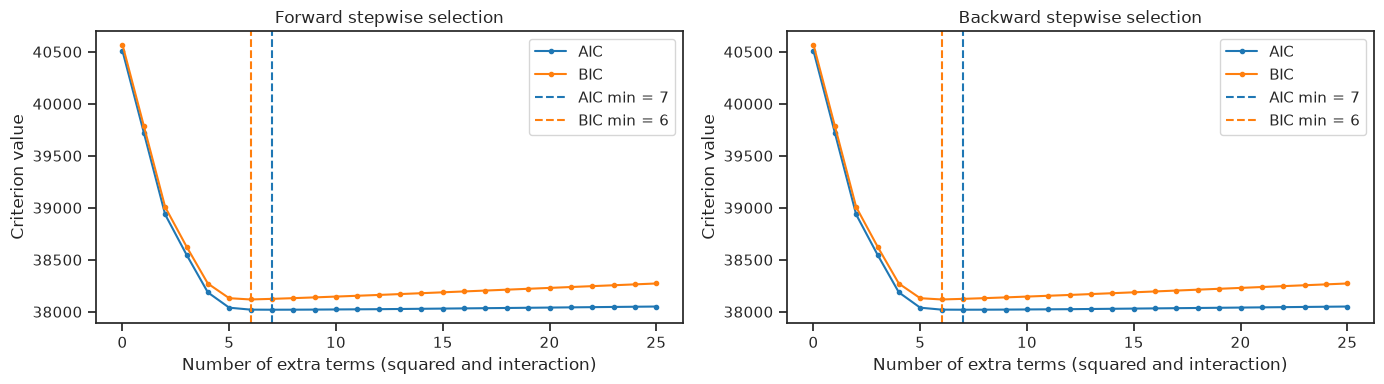

In [36]:
# AIC and BIC along the forward and backward paths
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
for i, (path, name) in enumerate([(forward_path, 'Forward'), (backward_path, 'Backward')]):
    ax[i].plot(path.index, path['AIC'], marker = 'o', markersize = 3, color = 'C0', label = 'AIC')
    ax[i].plot(path.index, path['BIC'], marker = 'o', markersize = 3, color = 'C1', label = 'BIC')
    # dashed vertical lines at the minimum of each criterion (the chosen number of extra terms)
    ax[i].axvline(path['AIC'].idxmin(), color = 'C0', linestyle = '--', label = 'AIC min = {}'.format(path['AIC'].idxmin()))
    ax[i].axvline(path['BIC'].idxmin(), color = 'C1', linestyle = '--', label = 'BIC min = {}'.format(path['BIC'].idxmin()))
    ax[i].set_xlabel('Number of extra terms (squared and interaction)')
    ax[i].set_ylabel('Criterion value')
    ax[i].set_title(name + ' stepwise selection')
    ax[i].legend()
plt.tight_layout()
plt.show()

**Result.** Starting from opposite ends, forward and backward selection end at exactly the same models (6 extra terms by BIC,
7 by AIC), so the selection is stable. In both plots AIC and BIC drop sharply over the first 5–6 terms and then rise slowly:
further terms improve the fit too little to justify their extra parameters.

### 3.8 M6: ridge, lasso and elastic net

Instead of choosing terms, all 32 columns are kept and large coefficients are penalised (Lectures 6–7):
ridge minimises $RSS + \lambda\sum_j\beta_j^2$ (L2: shrinks every coefficient) and lasso minimises $RSS + \lambda\sum_j|\beta_j|$
(L1: can set coefficients exactly to 0). The penalty depends on the scale of each column, so the predictors are standardised
first (Tutorial 7).

As in M4 and M5, the tuning parameter is chosen by AIC and BIC (Lectures 6–7, and the Tutorial 7 homework):
$AIC(\lambda) = n\log(\hat{\sigma}^2_\lambda) + 2\,df(\lambda)$ and $BIC(\lambda) = n\log(\hat{\sigma}^2_\lambda) + \log(n)\,df(\lambda)$,
where the effective degrees of freedom $df(\lambda)$ replace the number of parameters: for ridge
$df(\lambda) = \sum_j d_j^2/(d_j^2+\lambda)$ ($d_j^2$ = eigenvalues of $X'X$), for lasso $df(\lambda)$ = number of non-zero coefficients.
λ is searched over 30 values from 0.001 to 100 (log scale). The chosen models are then compared with the other models by the same 10-fold CV.

In [37]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Standardise with the mean and standard deviation of the training data (Tutorial 7); used only to compute AIC/BIC
# (no CV here, so using all training rows is fine; the penalty is fair only if all columns are on the same scale)
mu = X_all.mean()                        # mean for each column (32 values)
sigma = X_all.std()                      # std for each column (32 values)
X_std = (X_all - mu) / sigma             # every column now has mean 0 and std 1

# NOTE: not from tutorial — reason: ridge df(lambda) from the eigenvalues of X'X (Lectures 6-7, ridge: selection of lambda)
d2 = np.linalg.eigvalsh(X_std.T @ X_std) # eigenvalues d_j^2 of X'X (.T = transpose, @ = matrix product); computed once

alphas = np.logspace(-3, 2, 30)          # grid of 30 penalty values from 0.001 to 100, evenly spaced on a log scale
                                         # (scikit-learn calls the penalty λ "alpha")
m6_path = []                             # record book: one row per alpha
for alpha in alphas:                     # try each alpha once
    # Ridge (L2): fit once on all training data
    ridge = Ridge(alpha = alpha)                                    # ridge model with this penalty
    ridge.fit(X_std, y)                                             # estimate the 32 shrunken coefficients
    sigma2_hat = np.mean((y - ridge.predict(X_std)) ** 2)           # sigma2_hat = RSS / n (goodness of fit)
    df_ridge = np.sum(d2 / (d2 + alpha))                            # effective df of ridge: each term between 0 and 1
    ridge_aic = n * np.log(sigma2_hat) + 2 * df_ridge               # AIC(lambda) = fit + 2 * df
    ridge_bic = n * np.log(sigma2_hat) + np.log(n) * df_ridge       # BIC(lambda) = fit + log(n) * df

    # Lasso (L1): fit once on all training data
    lasso = Lasso(alpha = alpha, max_iter = 100000)                 # max_iter: allow more iterations so it converges
    lasso.fit(X_std, y)
    sigma2_hat = np.mean((y - lasso.predict(X_std)) ** 2)
    df_lasso = np.sum(lasso.coef_ != 0)                             # effective df of lasso = number of non-zero coefficients
    lasso_aic = n * np.log(sigma2_hat) + 2 * df_lasso
    lasso_bic = n * np.log(sigma2_hat) + np.log(n) * df_lasso

    m6_path.append({'alpha': alpha, 'Ridge df': df_ridge, 'Ridge AIC': ridge_aic, 'Ridge BIC': ridge_bic,
                    'Lasso df': df_lasso, 'Lasso AIC': lasso_aic, 'Lasso BIC': lasso_bic})   # record this alpha

m6_path = pd.DataFrame(m6_path)          # 30 rows, one per alpha
m6_path[['alpha', 'Ridge df', 'Lasso df']].round(4).iloc[::5]   # every 5th row: df falls as alpha grows

,alpha,Ridge df,Lasso df
0,0.0010,31.9992,32
5,0.0073,31.9939,29
10,0.0530,31.9562,23
15,0.3857,31.7201,18
20,2.8072,30.7735,16
25,20.4336,28.0892,9


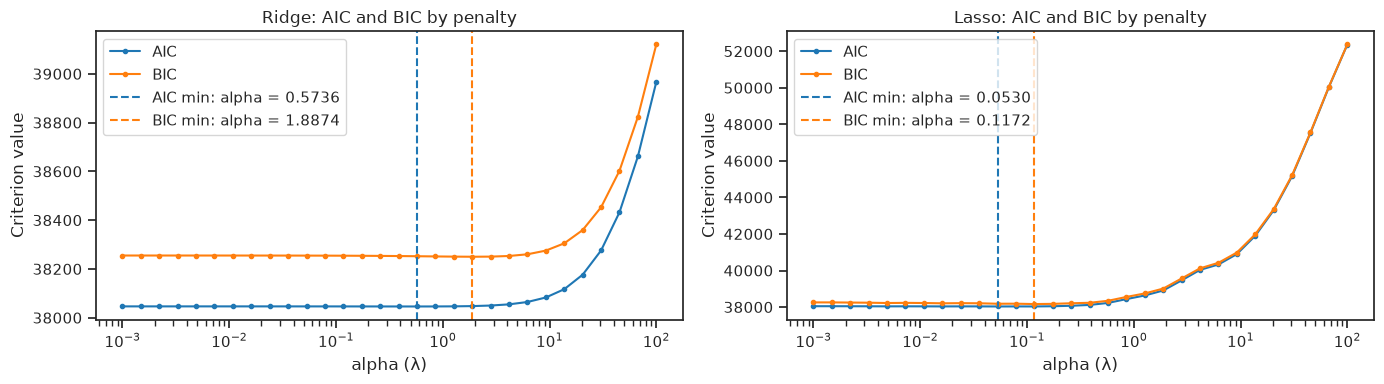

In [38]:
# AIC and BIC against alpha; dashed lines mark the minimum of each criterion (the chosen alpha)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))                    # left: ridge, right: lasso
for i, name in enumerate(['Ridge', 'Lasso']):                    # i = 0 (ridge), 1 (lasso)
    ax[i].plot(m6_path['alpha'], m6_path[name + ' AIC'], marker = 'o', markersize = 3, color = 'C0', label = 'AIC')   # column 'Ridge AIC' / 'Lasso AIC'
    ax[i].plot(m6_path['alpha'], m6_path[name + ' BIC'], marker = 'o', markersize = 3, color = 'C1', label = 'BIC')
    best_aic = m6_path.loc[m6_path[name + ' AIC'].idxmin(), 'alpha']   # alpha in the row with the smallest AIC
    best_bic = m6_path.loc[m6_path[name + ' BIC'].idxmin(), 'alpha']   # alpha in the row with the smallest BIC
    ax[i].axvline(best_aic, color = 'C0', linestyle = '--', label = 'AIC min: alpha = {:.4f}'.format(best_aic))
    ax[i].axvline(best_bic, color = 'C1', linestyle = '--', label = 'BIC min: alpha = {:.4f}'.format(best_bic))
    ax[i].set_xscale('log')                              # the λ grid is spread on a log scale
    ax[i].set_xlabel('alpha (λ)')
    ax[i].set_ylabel('Criterion value')
    ax[i].set_title(name + ': AIC and BIC by penalty')
    ax[i].legend()
plt.tight_layout()
plt.show()

In [39]:
# NOTE: not from tutorial — reason: make_pipeline puts the StandardScaler inside each CV fold, so the validation fold is
#       never used to compute the mean and standard deviation (decision at Checkpoint 0)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Evaluate the ridge and lasso models chosen by AIC and BIC with the same 10-fold CV as the other models
m6_summary = []                                                        # small table for M6 (4 rows)
for name in ['Ridge', 'Lasso']:                                        # 2 methods
    for criterion in ['AIC', 'BIC']:                                   # x 2 criteria = 4 models
        row = m6_path.loc[m6_path[name + ' ' + criterion].idxmin()]   # whole row with the smallest AIC (or BIC)
        alpha = row['alpha']                                           # the chosen alpha
        if name == 'Ridge':                                            # pipeline = standardise inside each fold -> model
            model = make_pipeline(StandardScaler(), Ridge(alpha = alpha))
        else:
            model = make_pipeline(StandardScaler(), Lasso(alpha = alpha, max_iter = 100000))
        mse, se = cv_mse(model, X_all)                                 # 10-fold CV (scaling inside each fold)
        results.append({'Model': 'M6: {} ({}, alpha = {:.4f})'.format(name, criterion, alpha), 'CV MSE': mse, 'SE': se})   # comparison table
        m6_summary.append({'Model': name, 'Criterion': criterion, 'alpha': alpha, 'df': row[name + ' df'],
                           'CV MSE': mse, 'SE': se})

pd.DataFrame(m6_summary).round(4)                                     # show the 4 models side by side

,Model,Criterion,alpha,df,CV MSE,SE
0,Ridge,AIC,0.5736,31.6089,2017.8835,27.1835
1,Ridge,BIC,1.8874,31.0525,2018.6737,26.4942
2,Lasso,AIC,0.0530,23.0000,2012.4817,25.8717
3,Lasso,BIC,0.1172,20.0000,2013.3032,25.1854


L1 versus L2 in practice: with the BIC choice of alpha, compare the ridge and lasso coefficients (standardised scale) and
count the ones that are exactly zero.

In [40]:
ridge_alpha = m6_path.loc[m6_path['Ridge BIC'].idxmin(), 'alpha']     # alpha chosen by BIC
lasso_alpha = m6_path.loc[m6_path['Lasso BIC'].idxmin(), 'alpha']
ridge_coef = Ridge(alpha = ridge_alpha).fit(X_std, y).coef_                          # fit, then take the 32 coefficients (standardised scale)
lasso_coef = Lasso(alpha = lasso_alpha, max_iter = 100000).fit(X_std, y).coef_ + 0.0   # + 0.0 turns -0.0 into 0.0 for display

# Summary: how many coefficients are exactly zero
zero_summary = pd.DataFrame({'Model': ['Ridge (L2)', 'Lasso (L1)'],
                             'alpha (BIC)': [ridge_alpha, lasso_alpha],
                             'Zero coefficients': [np.sum(ridge_coef == 0), np.sum(lasso_coef == 0)],   # == 0 gives True/False; sum counts True
                             'Non-zero coefficients': [np.sum(ridge_coef != 0), np.sum(lasso_coef != 0)]})
print(zero_summary.round(4).to_string(index = False))                  # index = False: no row numbers

# Only the terms the lasso sets to 0: ridge keeps a (small) coefficient for each of them
coef_table = pd.DataFrame({'Ridge': ridge_coef, 'Lasso': lasso_coef}, index = X_all.columns)
print('\nTerms dropped by the lasso:')
coef_table[coef_table['Lasso'] == 0].round(4)                          # keep only the rows where the lasso coefficient is 0

     Model  alpha (BIC)  Zero coefficients  Non-zero coefficients
Ridge (L2)       1.8874                  0                     32
Lasso (L1)       0.1172                 12                     20

Terms dropped by the lasso:


,Ridge,Lasso
Bedrooms_SQ,6.5276,0.0
DistanceCBD_x_FloorArea,-7.3705,0.0
DistanceCBD_x_PropertyAge,-0.0420,0.0
DistanceCBD_x_Furnished,-0.0374,0.0
Bedrooms_x_FloorArea,-15.5721,0.0
Bedrooms_x_PropertyAge,-0.4940,0.0
Bedrooms_x_NearTrain,-0.5940,0.0
FloorArea_x_PropertyAge,0.8430,0.0
FloorArea_x_Furnished,-0.4109,0.0
FloorArea_x_HighDemandArea,-2.2541,0.0


The lectures give no df formula for the elastic net, so its penalty is chosen by CV on a small grid (as in Tutorial 5).

In [41]:
# Elastic net: penalty = 90% L1 + 10% L2 (l1_ratio = 0.9); small grid so the cell runs quickly
enet_alphas = np.logspace(-2, 1, 10)     # 10 values from 0.01 to 10
enet_cv = []                             # CV MSE for each alpha
for alpha in enet_alphas:                # CV(lambda): 10-fold CV for each alpha (no df formula for the elastic net)
    mse, se = cv_mse(make_pipeline(StandardScaler(), ElasticNet(alpha = alpha, l1_ratio = 0.9, max_iter = 100000)), X_all)
    enet_cv.append(mse)

best_enet_alpha = enet_alphas[np.argmin(enet_cv)]        # alpha with the smallest CV MSE
mse, se = cv_mse(make_pipeline(StandardScaler(), ElasticNet(alpha = best_enet_alpha, l1_ratio = 0.9, max_iter = 100000)), X_all)   # rerun to get its SE
results.append({'Model': 'M6: Elastic net (CV, alpha = {:.4f}, l1_ratio = 0.9)'.format(best_enet_alpha), 'CV MSE': mse, 'SE': se})
print('Elastic net: alpha = {:.4f}, CV MSE {:.4f} (SE {:.4f})'.format(best_enet_alpha, mse, se))

Elastic net: alpha = 0.0100, CV MSE 2022.4385 (SE 25.0940)


**Result.** AIC and BIC choose small penalties: with 5000 rows and 32 columns, OLS barely overfits, so shrinkage gains little.
BIC chooses a larger alpha than AIC (simpler model). The lasso models have the lowest CV MSE of the penalised models, but
none beats the stepwise models, which use far fewer terms.

### 3.9 M7: K-nearest neighbours

KNN on the seven standardised predictors; k is chosen by CV (Tutorial 5).

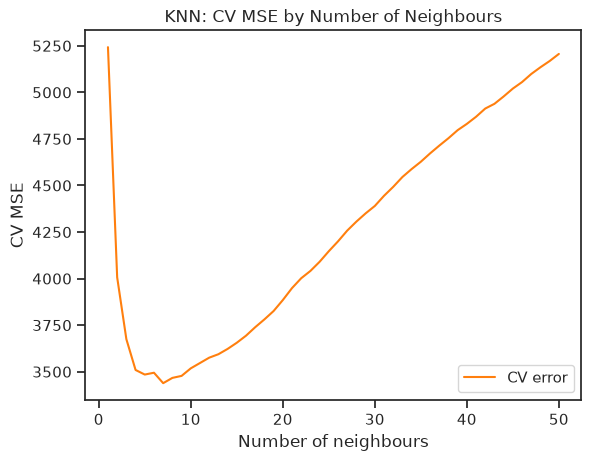

Best k = 7, CV MSE 3438.6270 (SE 69.4793)


In [42]:
from sklearn.neighbors import KNeighborsRegressor

neighbours = np.arange(1, 51)
knn_cv = []
for k in neighbours:
    knn = make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = k))
    mse, se = cv_mse(knn, train[predictors])
    knn_cv.append(mse)

fig, ax = plt.subplots()
ax.plot(neighbours, knn_cv, color='#FF7F0E', label='CV error')
ax.set_xlabel('Number of neighbours')
ax.set_ylabel('CV MSE')
ax.set_title('KNN: CV MSE by Number of Neighbours')
plt.legend()
plt.show()

best_k = neighbours[np.argmin(knn_cv)]
mse, se = cv_mse(make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors = best_k)), train[predictors])
results.append({'Model': 'M7: KNN (k = {})'.format(best_k), 'CV MSE': mse, 'SE': se})
print('Best k = {}, CV MSE {:.4f} (SE {:.4f})'.format(best_k, mse, se))

### 3.10 Model comparison

In [43]:
comparison_table = pd.DataFrame(results).set_index('Model').sort_values('CV MSE')
comparison_table.round(4)

,CV MSE,SE
Model,,
"M5: Backward stepwise (BIC), 6 extra terms",2005.6203,27.4624
"M4: Forward stepwise (BIC), 6 extra terms",2005.6203,27.4624
"M4: Forward stepwise (AIC), 7 extra terms",2005.8861,26.4687
"M5: Backward stepwise (AIC), 7 extra terms",2005.8861,26.4687
"M6: Lasso (AIC, alpha = 0.0530)",2012.4817,25.8717
"M6: Lasso (BIC, alpha = 0.1172)",2013.3032,25.1854
"M6: Ridge (AIC, alpha = 0.5736)",2017.8835,27.1835
"M6: Ridge (BIC, alpha = 1.8874)",2018.6737,26.4942
"M6: Elastic net (CV, alpha = 0.0100, l1_ratio = 0.9)",2022.4385,25.0940


**One-standard-error band.** Models whose CV MSE is below (best CV MSE + its SE) are not meaningfully less accurate than
the best model. The improvement over the linear model M1 is also shown.

In [44]:
best_name = comparison_table['CV MSE'].idxmin()                                  # model with the lowest CV MSE
one_se_threshold = comparison_table.loc[best_name, 'CV MSE'] + comparison_table.loc[best_name, 'SE']
m1_mse = comparison_table.loc['M1: OLS, 7 linear terms', 'CV MSE']
reduction = (m1_mse - comparison_table.loc[best_name, 'CV MSE']) / m1_mse * 100  # % reduction relative to M1

print('One-SE threshold: {:.4f}'.format(one_se_threshold))
print('Reduction in CV MSE relative to M1: {:.4f}%'.format(reduction))

One-SE threshold: 2033.0828
Reduction in CV MSE relative to M1: 39.2675%


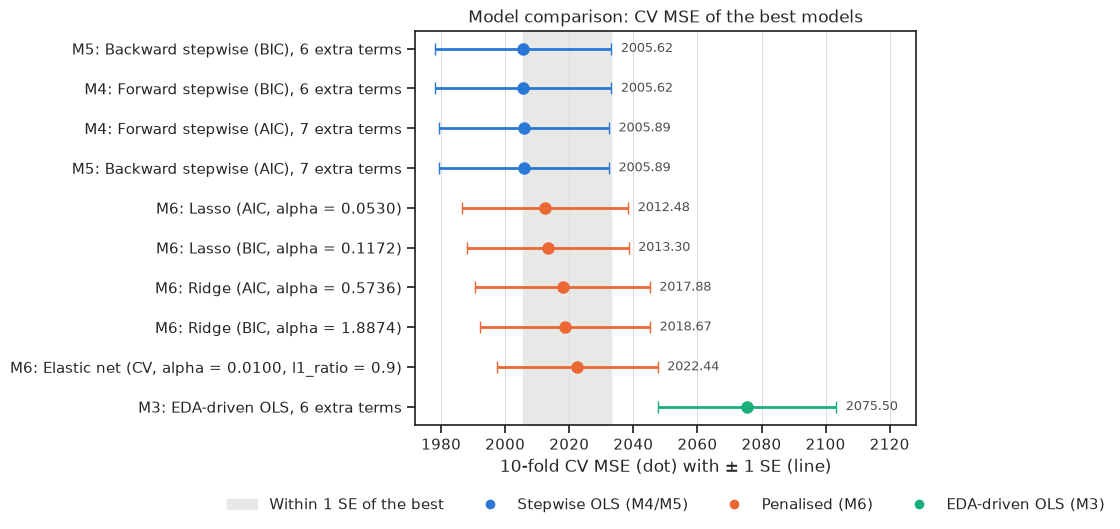

In [45]:
# Models close to the best one (M0, M1, the best subset and KNN have much larger errors, shown in the table above)
close = comparison_table[comparison_table['CV MSE'] < 2500]

# Colour by model family (fixed colours): stepwise OLS, penalised regression, EDA-driven OLS
family_colours = {'Stepwise OLS (M4/M5)': '#2a78d6', 'Penalised (M6)': '#eb6834', 'EDA-driven OLS (M3)': '#1baf7a'}
def family(name):
    if name.startswith('M4') or name.startswith('M5'):
        return 'Stepwise OLS (M4/M5)'
    elif name.startswith('M6'):
        return 'Penalised (M6)'
    else:
        return 'EDA-driven OLS (M3)'

best_mse = close['CV MSE'].min()
one_se_line = best_mse + close.loc[close['CV MSE'].idxmin(), 'SE']   # one-standard-error rule: best CV MSE + its SE

fig, ax = plt.subplots(figsize = (10, 5.5))
ypos = np.arange(len(close))                                         # one row per model, best at the top
ax.axvspan(best_mse, one_se_line, color = '#e8e8e6', zorder = 0, label = 'Within 1 SE of the best')   # shaded band
for i, (name, row) in enumerate(close.iterrows()):
    colour = family_colours[family(name)]
    ax.errorbar(row['CV MSE'], ypos[i], xerr = row['SE'], fmt = 'o', markersize = 8,
                color = colour, ecolor = colour, elinewidth = 2, capsize = 4)          # dot = CV MSE, line = +/- 1 SE
    ax.text(row['CV MSE'] + row['SE'] + 3, ypos[i], '{:.2f}'.format(row['CV MSE']),
            va = 'center', fontsize = 9, color = '#52514e')                           # value label next to each dot
ax.set_yticks(ypos)
ax.set_yticklabels(close.index)
ax.invert_yaxis()                                                    # best model at the top
ax.grid(axis = 'x', color = '#dddddd', linewidth = 0.8)              # light vertical grid only
ax.set_axisbelow(True)
ax.set_xlim(right = close['CV MSE'].max() + close['SE'].max() + 25)    # room for the value labels
ax.set_xlabel('10-fold CV MSE (dot) with ± 1 SE (line)')
ax.set_title('Model comparison: CV MSE of the best models')

# Legend: one entry per family plus the 1-SE band
for fam, colour in family_colours.items():
    ax.plot([], [], 'o', color = colour, label = fam)
ax.legend(loc = 'upper center', bbox_to_anchor = (0.5, -0.15), ncol = 4, frameon = False)   # legend below the plot
plt.tight_layout()
plt.show()

**Result.** Forward and backward stepwise (BIC) have the lowest CV MSE (2005.62). The stepwise (AIC) and all penalised models
fall inside the shaded one-standard-error band, so they perform about equally well; the EDA-driven OLS (M3) lies outside it.
Among the models in the band, the stepwise (BIC) model is recommended: it is the simplest (6 extra terms) and easy to interpret.

## 4. Final model

The final model is **M4: forward stepwise selection with BIC** (the same terms as M5 backward with BIC): the seven predictors
plus `DistanceCBD_SQ`, `Bedrooms_x_HighDemandArea`, `FloorArea_SQ`, `DistanceCBD_x_NearTrain`, `Bedrooms_x_Furnished` and
`PropertyAge_SQ`. It has the lowest CV MSE and is the simplest model within one standard error of the best.

### 4.1 Refit on all training data

During CV each fold's model was fitted on only 4500 rows and then discarded; CV was used only to *evaluate* the models.
After choosing the model, it is refitted once on all 5000 training rows (Lectures 4–5: "refit on the entire dataset"),
and this fitted model makes the test predictions.

In [46]:
final_terms = forward_path.loc[forward_path['BIC'].idxmin(), 'Terms']   # the 6 extra terms chosen by BIC (M4)
final_columns = predictors + final_terms                                # 7 + 6 = 13 columns

# statsmodels fit on all 5000 rows: coefficients, standard errors and p-values (as in Tutorial 7)
x_with_intercept = sm.add_constant(X_all[final_columns], prepend=True)
final_est = sm.OLS(y, x_with_intercept).fit()

# scikit-learn fit on all 5000 rows: the same coefficients, used for predictions (and in the final cell)
final_model = LinearRegression()
final_model.fit(X_all[final_columns], y)

coef_table = pd.DataFrame({'Coefficient': final_est.params, 'Std. error': final_est.bse, 'p-value': final_est.pvalues})
print('R-squared: {:.4f}'.format(final_est.rsquared))
print('Residual standard error: {:.4f} AUD'.format(np.sqrt(final_est.scale)))
print('Training MSE: {:.4f}   10-fold CV MSE: {:.4f}'.format(np.mean(final_est.resid ** 2),
      comparison_table.loc['M4: Forward stepwise (BIC), 6 extra terms', 'CV MSE']))
coef_table.round(4)

R-squared: 0.9570
Residual standard error: 44.7225 AUD
Training MSE: 1994.5021   10-fold CV MSE: 2005.6203


,Coefficient,Std. error,p-value
const,508.7797,6.0175,0.0
DistanceCBD,-24.8073,0.2657,0.0
Bedrooms,69.8025,1.4714,0.0
FloorArea,5.1093,0.1198,0.0
PropertyAge,-2.1358,0.1199,0.0
NearTrain,44.8414,2.2583,0.0
Furnished,48.9324,3.3210,0.0
HighDemandArea,84.5135,3.1737,0.0
DistanceCBD_SQ,0.2943,0.0067,0.0
Bedrooms_x_HighDemandArea,31.4845,1.2296,0.0


### 4.2 Business interpretation

Because of the squared and interaction terms, the effect of a predictor is not a single coefficient (for example, the effect of
`NearTrain` is $44.84 + 2.75 \times$ `DistanceCBD`). The table shows the predicted change in weekly rent for a property with
average characteristics when one predictor increases by one unit (or switches from 0 to 1), holding the others fixed.

In [47]:
# NOTE: not from tutorial — reason: with squared and interaction terms, effects are computed by comparing two predictions
average_property = train[predictors].mean().to_frame().T               # one row: the average of each predictor

effects = []
for var in predictors:
    low = average_property.copy()
    high = average_property.copy()
    if var in binary:                                                   # 0/1 variables: compare 0 with 1
        low[var] = 0
        high[var] = 1
    else:                                                               # numeric variables: add one unit
        high[var] = high[var] + 1
    change = final_model.predict(make_features(high)[final_columns])[0] - final_model.predict(make_features(low)[final_columns])[0]
    effects.append({'Predictor': var, 'Change in weekly rent (AUD)': change})

pd.DataFrame(effects).set_index('Predictor').round(4)

,Change in weekly rent (AUD)
Predictor,
DistanceCBD,-15.2928
Bedrooms,89.1557
FloorArea,3.0293
PropertyAge,-1.7943
NearTrain,81.9690
Furnished,88.2596
HighDemandArea,158.9050


**Train-station premium at different distances.** Because of the `DistanceCBD × NearTrain` interaction, the premium for being
near a train station changes with distance. Compare NearTrain = 1 with NearTrain = 0 for an average property at several distances.

In [48]:
for distance in [5, 20, 35]:
    low = average_property.copy()
    high = average_property.copy()
    low['DistanceCBD'] = distance                 # same distance in both rows
    high['DistanceCBD'] = distance
    low['NearTrain'] = 0
    high['NearTrain'] = 1
    premium = final_model.predict(make_features(high)[final_columns])[0] - final_model.predict(make_features(low)[final_columns])[0]
    print('Train-station premium at {} km: {:.4f}'.format(distance, premium))

Train-station premium at 5 km: 58.5823


Train-station premium at 20 km: 99.8050
Train-station premium at 35 km: 141.0276


**Marginal effects from the coefficients.** With a squared term, the slope of rent in x is b + 2 × b_SQ × x; with an
interaction, the slope of one variable adds the interaction coefficient when the other variable equals 1.

In [49]:
b = final_est.params                              # coefficients of the final model (statsmodels fit)

# Distance: slope = b_Distance + 2 * b_Distance_SQ * distance (property not near a train station)
for distance in [5, 30]:
    print('Rent change per extra km at {} km: {:.4f}'.format(distance, b['DistanceCBD'] + 2 * b['DistanceCBD_SQ'] * distance))

# Floor area: slope = b_FloorArea + 2 * b_FloorArea_SQ * area
for area in [50, 150]:
    print('Rent change per extra m² at {} m²: {:.4f}'.format(area, b['FloorArea'] + 2 * b['FloorArea_SQ'] * area))

# Bedrooms: the base slope plus the interaction coefficients that apply
print('Extra bedroom, not high-demand, not furnished: {:.4f}'.format(b['Bedrooms']))
print('Extra bedroom, high-demand, not furnished:     {:.4f}'.format(b['Bedrooms'] + b['Bedrooms_x_HighDemandArea']))
print('Extra bedroom, high-demand and furnished:      {:.4f}'.format(b['Bedrooms'] + b['Bedrooms_x_HighDemandArea'] + b['Bedrooms_x_Furnished']))

Rent change per extra km at 5 km: -21.8648
Rent change per extra km at 30 km: -7.1523
Rent change per extra m² at 50 m²: 3.9327
Rent change per extra m² at 150 m²: 1.5794
Extra bedroom, not high-demand, not furnished: 69.8025
Extra bedroom, high-demand, not furnished:     101.2870
Extra bedroom, high-demand and furnished:      117.9313


Holding other factors fixed, for an average property: being in a high-demand area adds about \$159 per week, being furnished
about \$88, being near a train station about \$82, and each extra bedroom about \$89; each extra square metre adds about \$3,
each extra km from the CBD reduces rent by about \$15, and each extra year of age by about \$1.8. The interactions show that an
extra bedroom is worth about \$31 more in high-demand areas and about \$17 more when furnished, and that the train-station
premium grows with distance from the CBD (about \$58 at 5 km, \$127 at 30 km).

### 4.3 Residual diagnostics

If the model is adequate, the residuals should scatter randomly around 0 with no pattern against the fitted values and be
roughly normal.

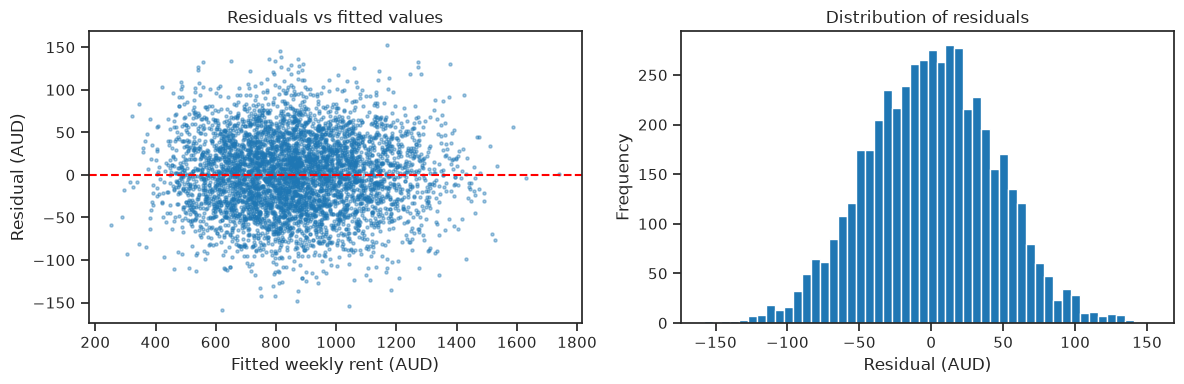

Residual skewness: -0.0131, kurtosis: 2.9714 (normal: 0 and 3)


In [50]:
fitted = final_est.fittedvalues
residuals = final_est.resid

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(fitted, residuals, s = 5, alpha = 0.4)
ax[0].axhline(0, color = 'red', linestyle = '--')                      # residuals should scatter around 0
ax[0].set_xlabel('Fitted weekly rent (AUD)')
ax[0].set_ylabel('Residual (AUD)')
ax[0].set_title('Residuals vs fitted values')
ax[1].hist(residuals, bins = 50)
ax[1].set_xlabel('Residual (AUD)')
ax[1].set_ylabel('Frequency')
ax[1].set_title('Distribution of residuals')
plt.tight_layout()
plt.show()

print('Residual skewness: {:.4f}, kurtosis: {:.4f} (normal: 0 and 3)'.format(residuals.skew(), residuals.kurt() + 3))

**Result.** The residuals show no clear pattern against the fitted values and are close to normal, so the squared and
interaction terms have captured the curvature that the linear model (M1) missed.

**Groups flagged in the outlier check (2.10).** Compare the mean residual of the linear model (M1) and the final model for
distant properties and five-bedroom properties; a mean close to 0 means no systematic under- or over-prediction.

In [51]:
# Residuals of the linear model M1, fitted on all training rows
m1_resid = sm.OLS(y, sm.add_constant(X_all[predictors], prepend=True)).fit().resid

groups = {'DistanceCBD >= 30': train['DistanceCBD'] >= 30,
          'DistanceCBD = 40':  train['DistanceCBD'] == 40,
          'Bedrooms = 5':      train['Bedrooms'] == 5}
group_table = pd.DataFrame({'Properties': [mask.sum() for mask in groups.values()],
                            'Mean residual (M1)': [m1_resid[mask].mean() for mask in groups.values()],
                            'Mean residual (final)': [residuals[mask].mean() for mask in groups.values()]},
                           index = groups.keys())
group_table.round(4)

,Properties,Mean residual (M1),Mean residual (final)
DistanceCBD >= 30,357,43.4255,-2.2093
DistanceCBD = 40,43,98.6376,-0.4439
Bedrooms = 5,199,-38.4459,1.4169


### 4.4 Test predictions

The same `make_features` function builds the 13 columns for the test data; the refitted model predicts the weekly rent.
The file has one column `WeeklyRent` and 1000 rows in the same order as `WeeklyRent_test_noLabel.csv`.

In [52]:
X_test = make_features(test)[final_columns]                            # same features as the training data
test_predictions = final_model.predict(X_test)

prediction_file = pd.DataFrame({'WeeklyRent': test_predictions})       # keeps the row order of the test file
prediction_file.to_csv('SID_Assignment1_prediction.csv', index = False)

# Checks on the saved file
check = pd.read_csv('SID_Assignment1_prediction.csv')
assert list(check.columns) == ['WeeklyRent']                           # exactly one column named WeeklyRent
assert len(check) == len(test) == 1000                                 # 1000 rows, one per test property
assert check['WeeklyRent'].notna().all()                               # no missing predictions
assert np.allclose(check['WeeklyRent'].values, final_model.predict(make_features(test)[final_columns]))   # same order as the test file
print('Prediction file saved: {} rows, mean {:.4f}, min {:.4f}, max {:.4f}'.format(
      len(check), check['WeeklyRent'].mean(), check['WeeklyRent'].min(), check['WeeklyRent'].max()))

Prediction file saved: 1000 rows, mean 854.9277, min 358.8839, max 1531.6752


### 4.5 Test MSE (marker only)

The final cell reads `WeeklyRent_test.csv`, builds the same features with `make_features`, predicts with `final_model` and
computes the test MSE on the original AUD scale. It is not executed before submission.

In [ ]:
import pandas as pd
WeeklyRent_test = pd.read_csv("WeeklyRent_test.csv")
# YOUR CODE HERE: code that produces the test MSE test_error
X_te = make_features(WeeklyRent_test)[final_columns]      # same 13 columns as the final model
y_te = WeeklyRent_test["WeeklyRent"]
test_error = np.mean((y_te - final_model.predict(X_te)) ** 2)   # test MSE on the original AUD scale
print(test_error)